Importation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler

import gseapy as gp

Loading Dataset

In [3]:
file_path = "GSE150910_raw_data.csv"

gse1509 = pd.read_csv(file_path, index_col=0)

gse1509.shape

(18838, 288)

In [4]:
gse1509.head()

,chp_26,chp_31,chp_34,chp_38,chp_1,chp_3,chp_4,chp_11,chp_5,chp_9,...,chp_106,chp_108,chp_109,chp_110,chp_111,chp_112,chp_113,chp_114,ipf_1125,ipf_1130
symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,1361,993,351,613,841,565,1093,6239,1714,1044,...,466,638,334,349,778,872,693,465,639,944
TNMD,5,13,0,0,0,6,3,4,0,0,...,0,0,0,0,0,0,0,0,0,0
DPM1,1929,2775,1894,2007,1436,1923,1956,4518,2411,2056,...,936,1162,1043,689,1006,870,1701,860,1387,2150
SCYL3,176,216,208,218,162,137,242,490,259,162,...,57,35,122,42,73,68,145,21,146,204
C1orf112,93,143,97,148,98,128,102,188,119,87,...,50,60,72,21,74,48,131,72,69,158


Creating Meta-data

In [6]:
samples = gse1509.columns.tolist()

group_labels = []
for s in samples:
    if "chp" in s:
        group_labels.append("CHP")
    elif "ipf" in s:
        group_labels.append("IPF")
    elif "control" in s:
        group_labels.append("Control")
    else:
        group_labels.append("Unknown")  

metadata = pd.DataFrame({
    "sample": samples,
    "group": group_labels
})

metadata.head()

,sample,group
0,chp_26,CHP
1,chp_31,CHP
2,chp_34,CHP
3,chp_38,CHP
4,chp_1,CHP


Data cleaning & filtering

In [7]:
gse_filtered = gse1509[gse1509.sum(axis=1) > 10]

print("Original genes:", gse1509.shape[0])
print("Filtered genes:", gse_filtered.shape[0])

Original genes: 18838
Filtered genes: 18432


Normalization

In [8]:
gse_log = np.log2(gse_filtered + 1)

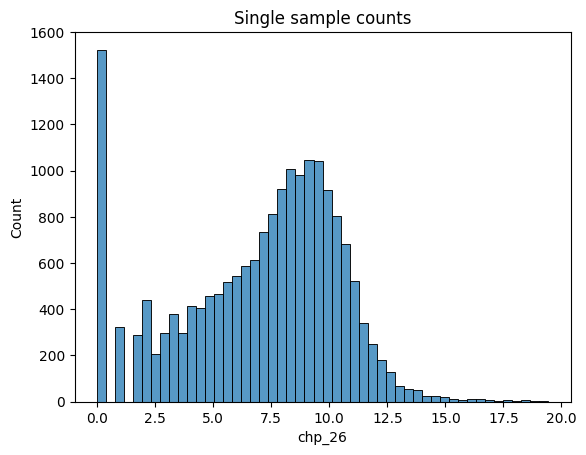

In [9]:
sns.histplot(gse_log.iloc[:,0], bins=50)
plt.title("Single sample counts")
plt.show()

Differential Expression Analysis

In [21]:
def differential_expression(df, metadata, group1, group2):
    
    samples1 = metadata[metadata['group'] == group1]['sample']
    samples2 = metadata[metadata['group'] == group2]['sample']
    
    data1 = df[samples1]
    data2 = df[samples2]
    
    results = []
    
    for symbol in df.index:
        vals1 = data1.loc[symbol]
        vals2 = data2.loc[symbol]
        
        stat, pval = stats.ttest_ind(vals1, vals2, equal_var=False)
        logFC = np.mean(vals1) - np.mean(vals2)
        
        results.append([symbol, logFC, pval])
    
    res_df = pd.DataFrame(results, columns=["symbol", "logFC", "pval"])
    res_df = res_df.dropna(subset=["pval"])
    res_df["adj_pval"] = multipletests(res_df["pval"], method="fdr_bh")[1]
    
    return res_df.sort_values("adj_pval")

Running comparisons

In [22]:
chp_vs_ctrl = differential_expression(gse_log, metadata, "CHP", "Control")
ipf_vs_ctrl = differential_expression(gse_log, metadata, "IPF", "Control")

chp_vs_ctrl.head()

,symbol,logFC,pval,adj_pval
1897,SEMA6A,-2.080807,1.470586e-38,2.709849e-34
5243,HIF3A,-2.669733,1.774556e-35,1.089992e-31
605,ARHGAP6,-1.671524,1.588761e-35,1.089992e-31
2943,DENND3,-1.664881,2.519866e-35,1.160839e-31
16392,GPX3,-2.152510,9.939452e-35,3.663085e-31


In [23]:
ipf_vs_ctrl.head()

,symbol,logFC,pval,adj_pval
16199,IGFL2,3.864643,1.898962e-47,3.499977e-43
4267,FHL2,1.953080,1.304569e-44,1.202225e-40
9659,ITLN2,-5.547994,5.074330e-42,3.117499e-38
13629,MAP3K15,-2.374308,1.792945e-41,8.261445e-38
6958,BAAT,3.193743,6.049843e-41,1.880266e-37


Volcano plot

In [16]:
def volcano_plot(df, title):
    plt.figure(figsize=(8,6))
    
    df['-log10(pval)'] = -np.log10(df['pval'])
    
    sns.scatterplot(
        x=df['logFC'],
        y=df['-log10(pval)'],
        hue=df['adj_pval'] < 0.05,
        palette={True: 'red', False: 'grey'},
        legend=False
    )
    
    plt.title(title)
    plt.xlabel("Log2 Fold Change")
    plt.ylabel("-log10(p-value)")
    plt.axhline(-np.log10(0.05), linestyle='--')
    plt.show()

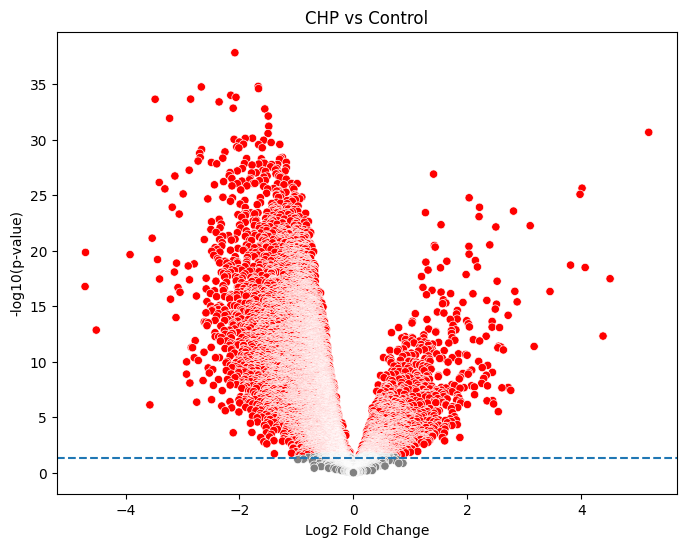

In [17]:
volcano_plot(chp_vs_ctrl, "CHP vs Control")

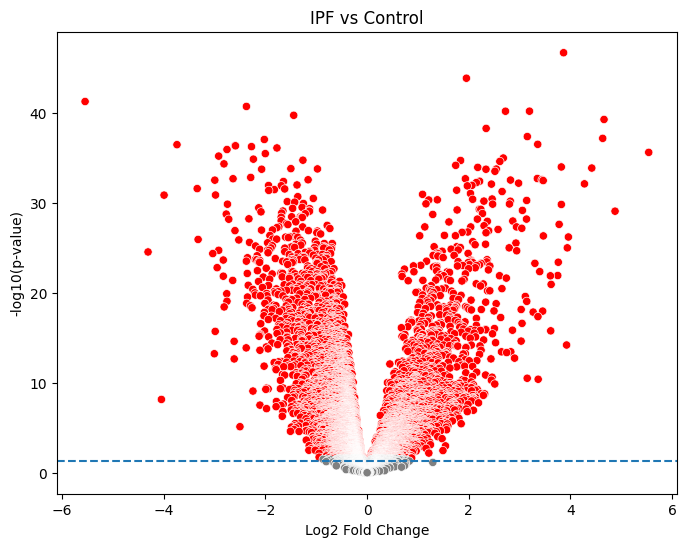

In [18]:
volcano_plot(ipf_vs_ctrl, "IPF vs Control")

Heatmap of Top DE Genes

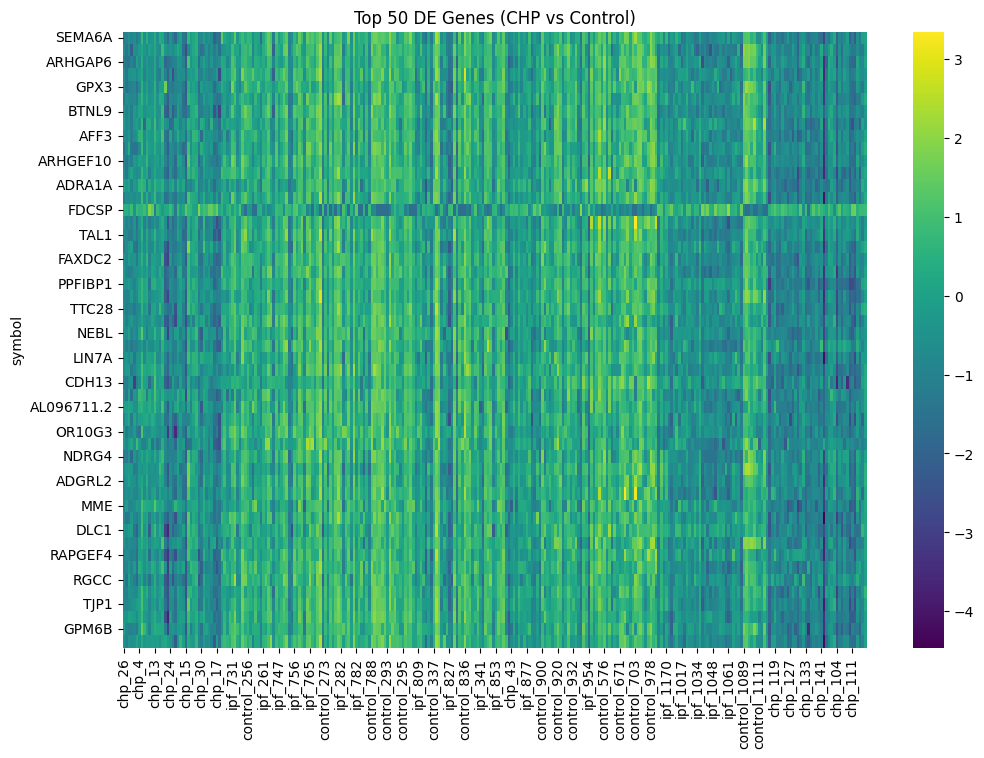

In [ ]:
top_genes = chp_vs_ctrl.head(50)['symbol']

heatmap_data = gse_log.loc[top_genes]

scaler = StandardScaler()
heatmap_scaled = pd.DataFrame(
    scaler.fit_transform(heatmap_data.T).T,
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

plt.figure(figsize=(12,8))
sns.heatmap(heatmap_scaled, cmap='viridis')
plt.title("Top 50 DE Genes (CHP vs Control)")
plt.show()

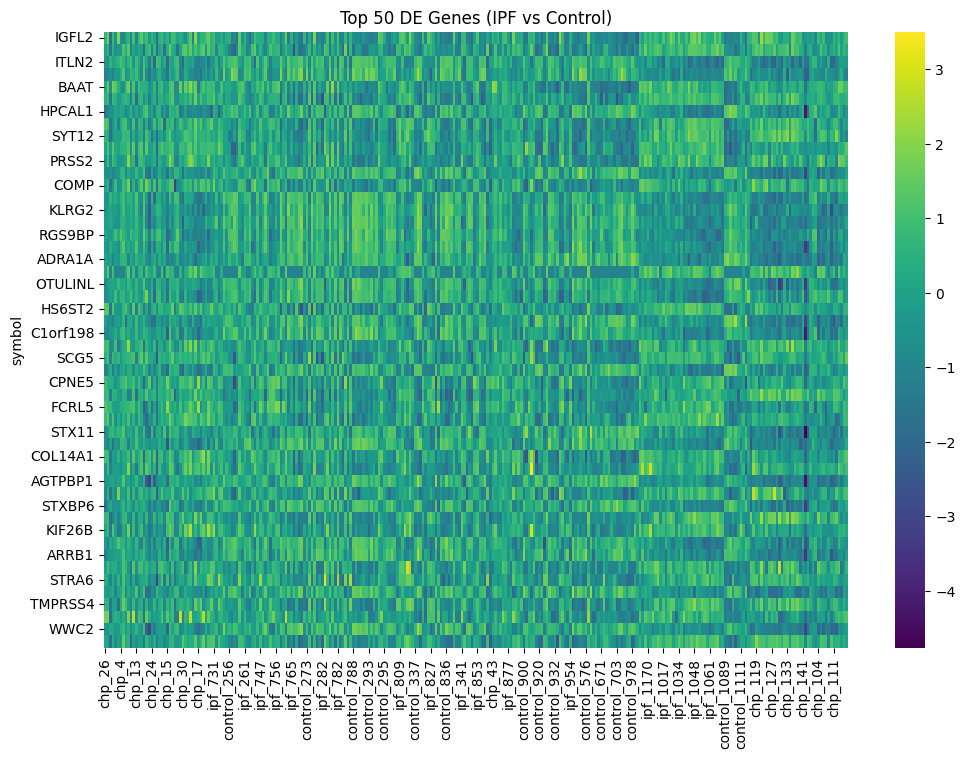

In [25]:
top_genes = ipf_vs_ctrl.head(50)['symbol']

heatmap_data = gse_log.loc[top_genes]

scaler = StandardScaler()
heatmap_scaled = pd.DataFrame(
    scaler.fit_transform(heatmap_data.T).T,
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

plt.figure(figsize=(12,8))
sns.heatmap(heatmap_scaled, cmap='viridis')
plt.title("Top 50 DE Genes (IPF vs Control)")
plt.show()

Pathway Enrichment(GO&KEGG)

In [32]:
sig_genes_chp = chp_vs_ctrl[
    (chp_vs_ctrl['adj_pval'] < 0.05) &
    (abs(chp_vs_ctrl['logFC']) > 1)
]['symbol'].tolist()

len(sig_genes_chp)

3293

In [33]:
sig_genes_ipf = ipf_vs_ctrl[
    (ipf_vs_ctrl['adj_pval'] < 0.05) &
    (abs(ipf_vs_ctrl['logFC']) > 1)
]['symbol'].tolist()

len(sig_genes_ipf)

1540

GO Enrichment

In [37]:
enr_go_chp = gp.enrichr(
    gene_list=sig_genes_chp,
    organism='hsapiens',
    gene_sets=['GO_Biological_Process_2023'],
    outdir=None
)

enr_go_chp.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Regulation Of Angiogenesis (GO:0045765),65/205,4.784670e-08,0.000231,0,0,2.382844,40.163469,SEMA5A;BTG1;CXCL8;FLT1;PDE3B;PTPRM;CXCL13;TSPA...
1,GO_Biological_Process_2023,Positive Regulation Of Angiogenesis (GO:0045766),43/119,1.576935e-07,0.000335,0,0,2.895275,45.347574,SEMA5A;BTG1;CXCL8;FLT1;GATA6;TWIST1;GATA2;FUT1...
2,GO_Biological_Process_2023,Regulation Of Cell Migration (GO:0030334),113/434,2.083905e-07,0.000335,0,0,1.813925,27.905148,SEMA5A;RIPOR1;CSF1;FAM107A;ARID4A;IGF1R;CDH5;F...
3,GO_Biological_Process_2023,Regulation Of Endothelial Cell Proliferation (...,34/93,2.229609e-06,0.002622,0,0,2.943775,38.309358,SEMA5A;BMPR2;CCL11;FLT4;PTPRM;FUT2;FUT1;THBS1;...
4,GO_Biological_Process_2023,Inflammatory Response (GO:0006954),67/236,2.716344e-06,0.002622,0,0,2.032388,26.047546,ORM1;CXCL9;NRROS;CXCL8;ADM;F11R;CXCL13;CXCL3;C...


In [38]:
enr_go_ipf = gp.enrichr(
    gene_list=sig_genes_ipf,
    organism='hsapiens',
    gene_sets=['GO_Biological_Process_2023'],
    outdir=None
)

enr_go_ipf.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Extracellular Structure Organization (GO:0043062),31/109,9.515523e-11,1.762553e-07,0,0,4.841396,111.717691,COL17A1;HPSE2;COL14A1;ADAMTS16;ADAMTS4;ADAMTS1...
1,GO_Biological_Process_2023,External Encapsulating Structure Organization ...,31/110,1.228304e-10,1.762553e-07,0,0,4.779853,109.077270,COL17A1;HPSE2;COL14A1;ADAMTS16;ADAMTS4;ADAMTS1...
2,GO_Biological_Process_2023,Cilium Movement (GO:0003341),22/59,1.530437e-10,1.762553e-07,0,0,7.216216,163.088636,CFAP61;SPAG17;DNAI2;RSPH4A;CFAP73;SPEF1;DNAH7;...
3,GO_Biological_Process_2023,Adenylate Cyclase-Activating G Protein-Coupled...,29/110,2.673073e-09,2.308867e-06,0,0,4.354822,85.964345,CALCA;RAMP2;CALCRL;RAMP3;ADRB1;ADRA1D;ADRB2;AD...
4,GO_Biological_Process_2023,Extracellular Matrix Organization (GO:0030198),37/176,1.622380e-08,1.121065e-05,0,0,3.244719,58.199835,COL17A1;PRSS1;HPSE2;COL14A1;ADAMTS16;ADAMTS4;A...


KEGG Enrichment

In [39]:
enr_kegg_chp = gp.enrichr(
    gene_list=sig_genes_chp,
    organism='hsapiens',
    gene_sets=['KEGG_2021_Human'],
    outdir=None
)

enr_kegg_chp.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Malaria,20/50,0.000062,0.012821,0,0,3.396884,32.936525,CSF3;GYPA;CXCL8;GYPB;HGF;SDC2;HBB;HBA1;THBS1;T...
1,KEGG_2021_Human,AMPK signaling pathway,36/120,0.000157,0.012821,0,0,2.187333,19.163610,PFKFB2;PRKAA1;CAB39;PIK3R1;HMGCR;ADIPOR1;ACACB...
2,KEGG_2021_Human,Hypertrophic cardiomyopathy,29/90,0.000171,0.012821,0,0,2.424532,21.031666,RYR2;PRKAA1;LAMA2;ITGB4;ITGA2B;CACNA1D;ACTB;TT...
3,KEGG_2021_Human,AGE-RAGE signaling pathway in diabetic complic...,31/100,0.000228,0.012821,0,0,2.291552,19.213610,CDKN1B;CXCL8;PIK3R1;AGER;FOXO1;ICAM1;MAPK8;AKT...
4,KEGG_2021_Human,Dilated cardiomyopathy,30/96,0.000245,0.012821,0,0,2.318140,19.277247,RYR2;LAMA2;ITGB4;ITGA2B;ADCY4;ADRB1;CACNA1D;AD...


In [40]:
enr_kegg_ipf = gp.enrichr(
    gene_list=sig_genes_ipf,
    organism='hsapiens',
    gene_sets=['KEGG_2021_Human'],
    outdir=None
)

enr_kegg_ipf.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Viral protein interaction with cytokine and cy...,23/100,0.000002,0.000461,0,0,3.619661,48.313982,CX3CR1;CCL25;CXCL6;CCL13;CCL24;IL20;CCL11;CCL2...
1,KEGG_2021_Human,Neuroactive ligand-receptor interaction,51/341,0.000004,0.000523,0,0,2.146013,26.886167,NPFFR2;CHRM2;GABRB2;CHRM3;PRSS1;VIPR1;CHRM1;AD...
2,KEGG_2021_Human,Vascular smooth muscle contraction,26/133,0.000009,0.000657,0,0,2.945580,34.344436,CALCA;RAMP2;CALCRL;RAMP3;CALML5;NPR1;PLA2G1B;C...
3,KEGG_2021_Human,ECM-receptor interaction,20/88,0.000009,0.000657,0,0,3.558824,41.308106,ITGB4;LAMC3;ITGA2B;LAMA3;TNC;NPNT;THBS2;THBS4;...
4,KEGG_2021_Human,Salivary secretion,20/93,0.000022,0.001256,0,0,3.314167,35.584417,CHRM3;GUCY1A2;CALML5;AMY1A;ATP1A4;ADRA1D;CALML...


Plot Enrichment

<Axes: title={'center': 'GO Enrichment'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

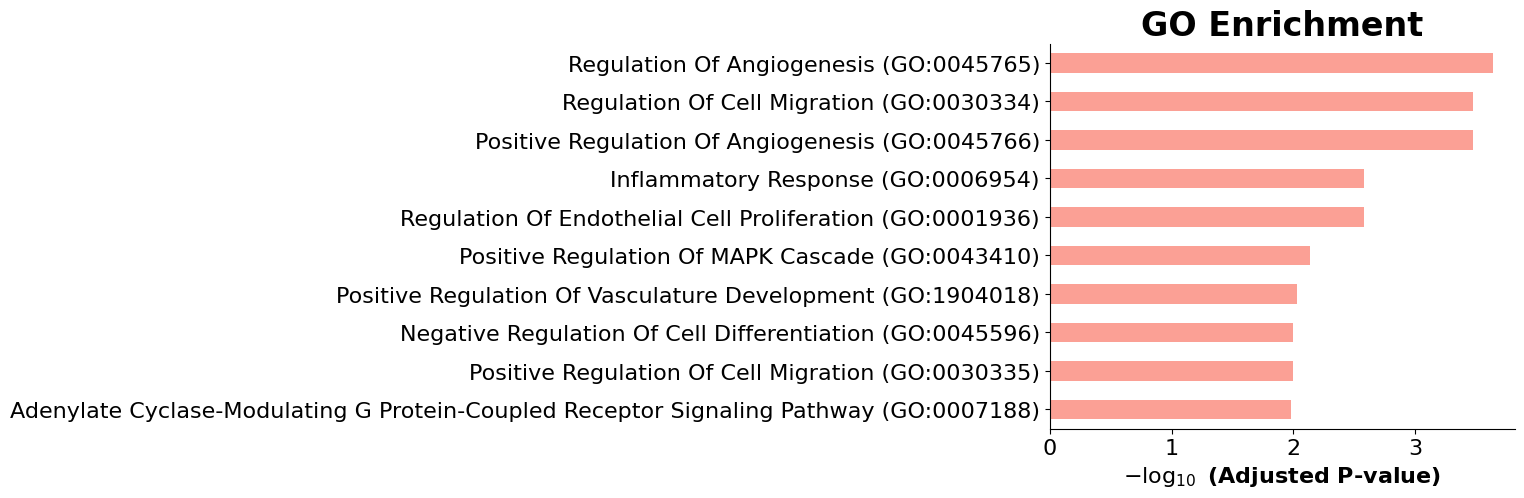

In [41]:
gp.barplot(enr_go_chp.results, title="GO Enrichment", figsize=(6,5))

<Axes: title={'center': 'KEGG Pathways'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

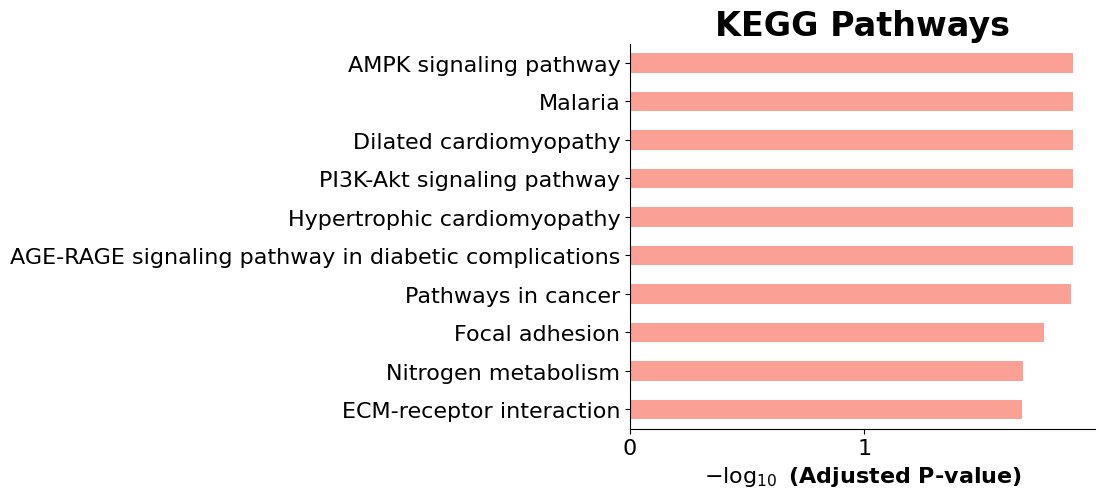

In [42]:
gp.barplot(enr_kegg_chp.results, title="KEGG Pathways", figsize=(6,5))

<Axes: title={'center': 'GO Enrichment'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

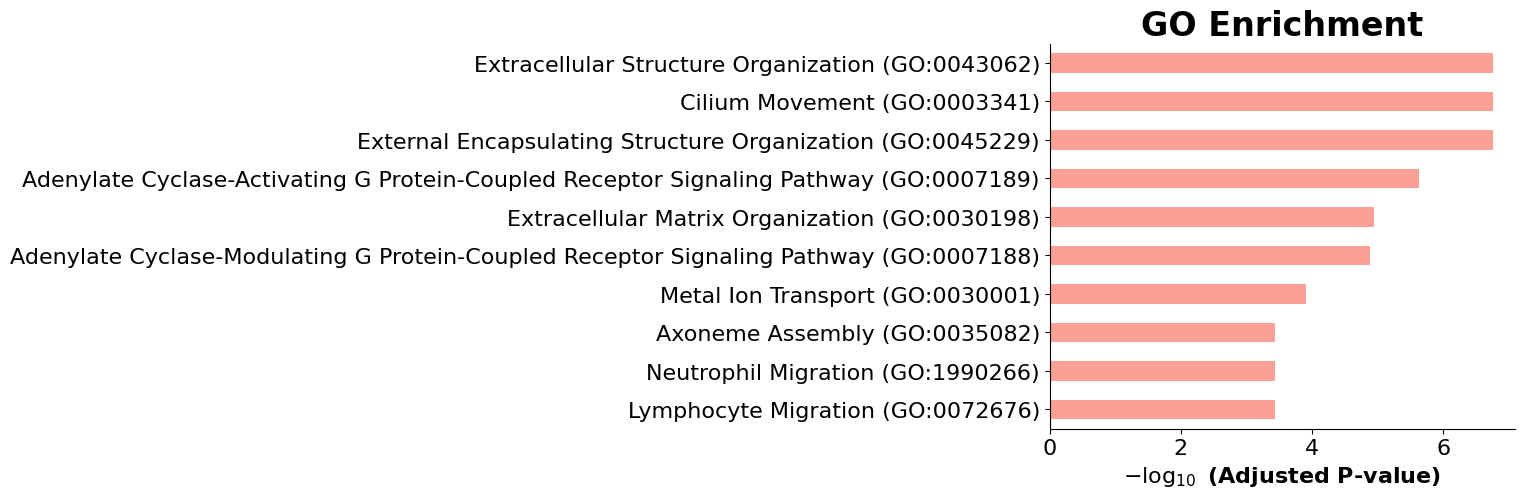

In [43]:
gp.barplot(enr_go_ipf.results, title="GO Enrichment", figsize=(6,5))

<Axes: title={'center': 'KEGG Pathways'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

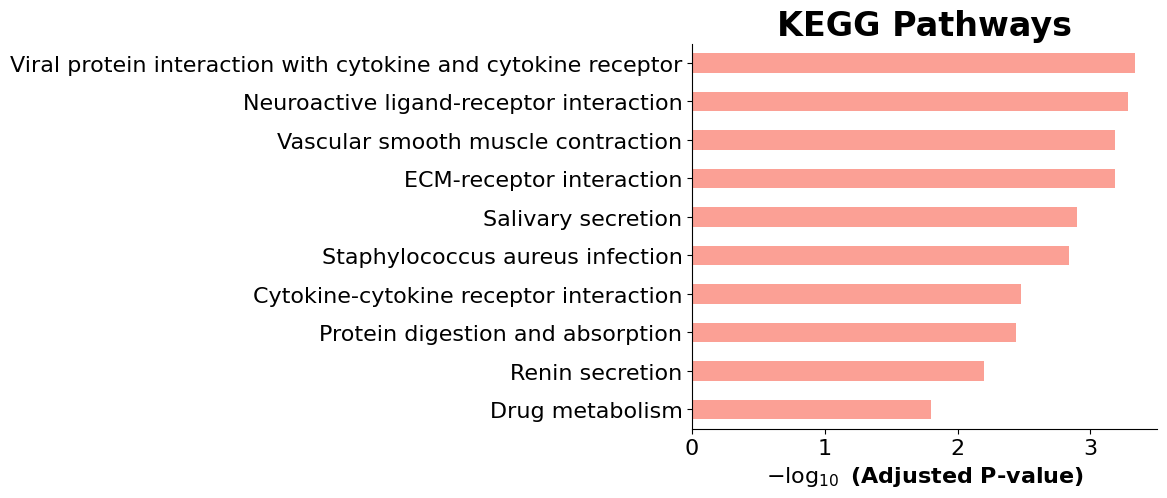

In [44]:
gp.barplot(enr_kegg_ipf.results, title="KEGG Pathways", figsize=(6,5))